# Data Vortex Aaruush '26 – Social Engine Data Recovery & EDA

## Project Overview

In this project, we worked on recovering and analyzing a corrupted social-engine dataset.

We first inspected the original dataset to understand the data quality issues. We then cleaned the data by removing exact duplicates, handling missing values, correcting negative engagement values based on a documented assumption, standardizing timestamps, and cleaning text formatting.

After cleaning the dataset, we performed exploratory data analysis to understand posting patterns and user engagement.

This notebook contains the complete cleaning and EDA workflow so that the results can be reproduced and reviewed easily.

## Dataset Description

The main dataset used in this project is `Social_Engine_Posts_Corrupted.csv`.

It contains social media post information with the following columns:

- `post_id` – Unique identifier for each post
- `user_id` – Identifier of the user who created the post
- `platform` – Social media platform
- `text_content` – Text associated with the post
- `timestamp` – Date and time of the post
- `likes` – Number of likes received
- `shares` – Number of shares
- `comments` – Number of comments

The original dataset contains 12,360 rows and 8 columns.

We also used `Social_Engine_Users.csv` to verify the relationship between users and posts. The posts dataset contains 1,500 unique user IDs, and all of them were found in the users dataset.

In [4]:
import pandas as pd
import re
import html

# Loading the original corrupted dataset
df = pd.read_csv("Social_Engine_Posts_Corrupted.csv")

# Checking the size of the dataset
print("Dataset shape:", df.shape)

# Checking the column names
print("\nColumn names:")
print(df.columns.tolist())

# Displaying the first few rows to understand the data
print("\nFirst five rows:")
display(df.head())

# Checking the missing values in each column
print("\nMissing values:")
print(df.isnull().sum())

# Checking how many completely duplicated rows are present
print("\nDuplicate rows:", df.duplicated().sum())

# Checking repeated post IDs
print("Repeated post IDs:", df["post_id"].duplicated().sum())

Dataset shape: (12360, 8)

Column names:
['post_id', 'user_id', 'platform', 'text_content', 'timestamp', 'likes', 'shares', 'comments']

First five rows:


,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,25-09-2024,4488.0,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,1722528840,789.0,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13T20:12:18,NaN,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,10-09-2024,167.0,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,31-05-2024,4749.0,152,630



Missing values:
post_id            0
user_id            0
platform        1846
text_content    1746
timestamp          0
likes           1858
shares             0
comments           0
dtype: int64

Duplicate rows: 360
Repeated post IDs: 360


In [5]:
# Checking the engagement columns to find unusual values
print("Minimum engagement values:")
print(df[["likes", "shares", "comments"]].min())

print("\nMaximum engagement values:")
print(df[["likes", "shares", "comments"]].max())

# Checking how many negative values are present in the likes column
# Likes should normally be zero or positive
negative_likes = (df["likes"] < 0).sum()

print("\nNegative likes:", negative_likes)

# Displaying a few negative likes so we can inspect the corrupted values
print("\nSample negative likes:")
display(
    df[df["likes"] < 0][
        ["post_id", "user_id", "likes", "shares", "comments"]
    ].head(10)
)

Minimum engagement values:
likes      -4987.0
shares         0.0
comments       0.0
dtype: float64

Maximum engagement values:
likes       5000.0
shares      2000.0
comments    1000.0
dtype: float64

Negative likes: 525

Sample negative likes:


,post_id,user_id,likes,shares,comments
20,mbykzpzh1l1y,user_750rlmnw,-4812.0,1777,553
94,wal886ggp7kg,user_e3cwapff,-1795.0,454,350
153,38tm1xfxxsdi,user_r7o639pp,-3707.0,957,49
163,yktgh97ttawi,user_ral75hq0,-4543.0,363,703
188,loscndnlqi7b,user_xyvxp8vz,-3194.0,904,378
192,hvjh643oxb8e,user_puypdmp1,-3616.0,1728,363
197,0c0tc7wbhqdu,user_m2ziq5ox,-1165.0,709,403
263,dnhsqcx3t94w,user_oknxkzax,-738.0,980,503
266,5fbt4nzjxol9,user_t2e8zk5w,-851.0,1959,185
268,whsvb3faauwf,user_uod57rwt,-1205.0,1413,976


In [6]:
# Removing exact duplicate rows
# These rows contain the same information and would count the same post more than once

original_rows = len(df)

df = df.drop_duplicates().copy()

removed_rows = original_rows - len(df)

print("Rows before removing duplicates:", original_rows)
print("Duplicate rows removed:", removed_rows)
print("Rows after removing duplicates:", len(df))

Rows before removing duplicates: 12360
Duplicate rows removed: 360
Rows after removing duplicates: 12000


In [7]:
# Checking how many platform values are missing after removing duplicates
print("Missing platform values:", df["platform"].isna().sum())

# We do not want to guess the platform because there is no reliable
# information to determine which platform these posts came from.
# Using "Unknown" keeps the records instead of deleting them.
df["platform"] = df["platform"].fillna("Unknown")

# Checking the platform counts after handling missing values
print("\nPlatform distribution:")
print(df["platform"].value_counts())

Missing platform values: 1784

Platform distribution:
platform
Facebook     2074
YouTube      2073
Twitter      2049
Reddit       2031
Instagram    1989
Unknown      1784
Name: count, dtype: int64


In [8]:
# Checking how many negative likes are still present
print("Negative likes before correction:", (df["likes"] < 0).sum())

# We assume the negative sign is caused by sign-flip corruption.
# Taking the absolute value keeps the original magnitude of the likes.
# Missing values are not affected by abs().
df["likes"] = df["likes"].abs()

# Checking the result after correction
print("Negative likes after correction:", (df["likes"] < 0).sum())

Negative likes before correction: 509
Negative likes after correction: 0


In [9]:
# Checking how many text values are missing
print("Missing text before cleaning:", df["text_content"].isna().sum())

# Cleaning the text without creating any new content
# Missing values are kept as missing
def clean_text(value):
    if pd.isna(value):
        return value

    # Converting HTML entities such as &amp; into normal characters
    value = html.unescape(str(value))

    # Removing extra spaces, tabs and line breaks
    value = re.sub(r"\s+", " ", value)

    # Removing unnecessary spaces from the beginning and end
    value = value.strip()

    return value

# Applying the cleaning function to the text column
df["text_content"] = df["text_content"].apply(clean_text)

# Checking the missing values after cleaning
print("Missing text after cleaning:", df["text_content"].isna().sum())

# Displaying a few cleaned text examples
print("\nSample cleaned text:")
display(df[["post_id", "text_content"]].head(10))

Missing text before cleaning: 1688
Missing text after cleaning: 1688

Sample cleaned text:


,post_id,text_content
0,to64mgey2v3y,Bummed out with my new Air Max from Nike! Abso...
1,7f0wdauzbj89,My one month review of Pepsi Crystal Pepsi: Hi...
2,dvvhg8eel45x,Just unboxed my new Highlander from Toyota. Ex...
3,hgb9cxke4t7b,Comparing Pepsi Crystal Pepsi to the competiti...
4,zwerpw3wk320,My one week review of Coca-Cola Diet Coke: Bes...
5,f85c8vm8ac8l,Adidas ValentinesDeals is disappointing! Can't...
6,19ys654yi1if,Fed up with my new iPhone 15 from Apple! Best ...
7,5jywsz1bu0kp,Just unboxed my new React from Nike. Not bad. ...
8,ol0ai4w126p0,Just saw an ad for Toyota Highlander during th...
9,irjlew2pr8sw,Just unboxed my new iMac from Apple. Disappoin...


In [10]:
# Checking the different timestamp formats before converting them
print("Sample timestamps before conversion:")
display(df["timestamp"].head(10))

# Converting the different timestamp formats into one datetime format
def parse_timestamp(value):

    # Keeping missing timestamps as missing
    if pd.isna(value):
        return pd.NaT

    value = str(value).strip()

    # Handling Unix timestamp values
    if re.fullmatch(r"\d+", value):
        return pd.to_datetime(
            int(value),
            unit="s",
            errors="coerce"
        )

    # Handling DD-MM-YYYY dates
    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", value):
        return pd.to_datetime(
            value,
            format="%d-%m-%Y",
            errors="coerce"
        )

    # Handling ISO-style timestamps
    return pd.to_datetime(value, errors="coerce")

# Applying the conversion to the timestamp column
df["timestamp"] = df["timestamp"].apply(parse_timestamp)

# Checking whether any timestamps failed to convert
print("\nTimestamp conversion failures:", df["timestamp"].isna().sum())

# Displaying the converted timestamps
print("\nSample timestamps after conversion:")
display(df["timestamp"].head(10))

Sample timestamps before conversion:


0             25-09-2024
1             1722528840
2    2025-04-13T20:12:18
3             10-09-2024
4             31-05-2024
5             24-01-2025
6             1719394663
7    2025-03-27T13:44:32
8    2024-05-05T05:52:34
9             11-02-2025
Name: timestamp, dtype: str


Timestamp conversion failures: 0

Sample timestamps after conversion:


0   2024-09-25 00:00:00
1   2024-08-01 16:14:00
2   2025-04-13 20:12:18
3   2024-09-10 00:00:00
4   2024-05-31 00:00:00
5   2025-01-24 00:00:00
6   2024-06-26 09:37:43
7   2025-03-27 13:44:32
8   2024-05-05 05:52:34
9   2025-02-11 00:00:00
Name: timestamp, dtype: datetime64[us]

In [11]:
# Checking the final dataset after all cleaning steps
print("Final dataset shape:", df.shape)

# Checking that no exact duplicate rows remain
print("Remaining duplicate rows:", df.duplicated().sum())

# Checking that no negative likes remain
print("Remaining negative likes:", (df["likes"] < 0).sum())

# Checking that the timestamp column has no conversion failures
print("Missing timestamps:", df["timestamp"].isna().sum())

# Checking the remaining missing values
print("\nRemaining missing values:")
print(df.isna().sum())

Final dataset shape: (12000, 8)
Remaining duplicate rows: 0
Remaining negative likes: 0
Missing timestamps: 0

Remaining missing values:
post_id            0
user_id            0
platform           0
text_content    1688
timestamp          0
likes           1814
shares             0
comments           0
dtype: int64


In [12]:
# Checking the final dataset after all cleaning steps
print("Final dataset shape:", df.shape)

# Checking that no exact duplicate rows remain
print("Remaining duplicate rows:", df.duplicated().sum())

# Checking that no negative likes remain
print("Remaining negative likes:", (df["likes"] < 0).sum())

# Checking that the timestamp column has no conversion failures
print("Missing timestamps:", df["timestamp"].isna().sum())

# Checking the remaining missing values
print("\nRemaining missing values:")
print(df.isna().sum())

Final dataset shape: (12000, 8)
Remaining duplicate rows: 0
Remaining negative likes: 0
Missing timestamps: 0

Remaining missing values:
post_id            0
user_id            0
platform           0
text_content    1688
timestamp          0
likes           1814
shares             0
comments           0
dtype: int64


In [13]:
# Saving the cleaned dataset as a separate CSV file
# The original corrupted dataset is kept unchanged for comparison
output_file = "Social_Engine_Posts_Cleaned.csv"

df.to_csv(output_file, index=False)

print("Cleaned dataset saved as:", output_file)

Cleaned dataset saved as: Social_Engine_Posts_Cleaned.csv


## Exploratory Data Analysis

After cleaning the dataset, we explored the data to understand posting patterns, platform activity, engagement levels, and relationships between engagement metrics.

In [14]:
# Calculating basic statistics for the engagement columns
engagement_columns = ["likes", "shares", "comments"]

print("Basic engagement statistics:")
display(df[engagement_columns].describe())

Basic engagement statistics:


,likes,shares,comments
count,10186.000000,12000.000000,12000.00000
mean,2491.864716,1007.167167,504.34575
std,1437.826281,575.072282,288.68416
min,0.000000,0.000000,0.00000
25%,1236.000000,510.000000,253.00000
50%,2498.000000,1018.000000,503.00000
75%,3722.750000,1501.000000,755.00000
max,5000.000000,2000.000000,1000.00000


Posts by platform:
platform
Facebook     2074
YouTube      2073
Twitter      2049
Reddit       2031
Instagram    1989
Unknown      1784
Name: count, dtype: int64


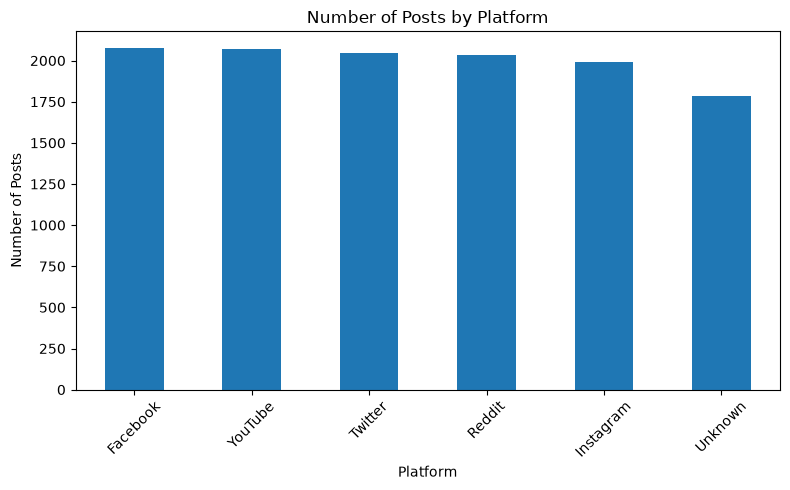

In [15]:
import matplotlib.pyplot as plt

# Counting the number of posts from each platform
platform_counts = df["platform"].value_counts()

print("Posts by platform:")
print(platform_counts)

# Creating a bar chart to compare the number of posts
plt.figure(figsize=(8, 5))
platform_counts.plot(kind="bar")

plt.title("Number of Posts by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.tight_layout()

# Saving the chart so it can also be used in the EDA report
plt.savefig("01_posts_by_platform.png", dpi=300)
plt.show()

Average engagement by platform:


,likes,shares,comments
platform,,,
Facebook,2528.86,984.17,506.94
Instagram,2500.93,1040.84,499.80
Reddit,2488.11,1002.23,511.18
Twitter,2437.69,1005.39,506.13
Unknown,2475.11,998.61,496.54
YouTube,2517.77,1011.83,504.38


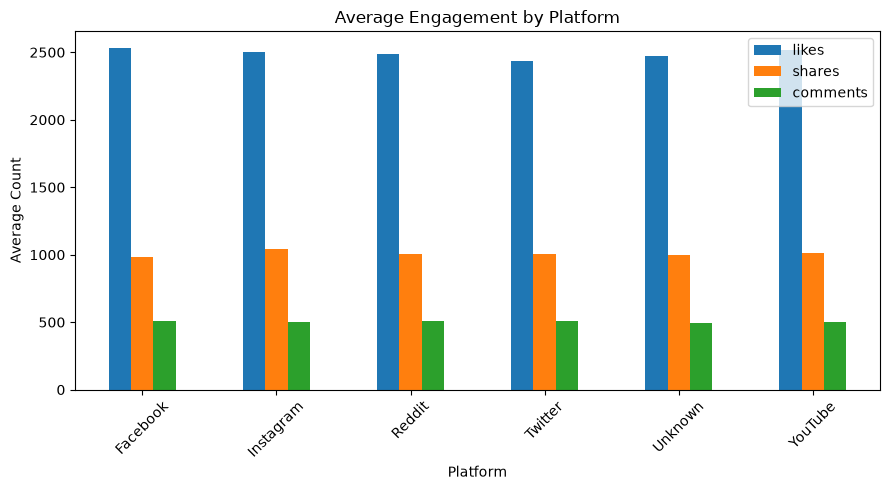

In [16]:
# Calculating the average likes, shares and comments for each platform
average_engagement = df.groupby("platform")[
    ["likes", "shares", "comments"]
].mean()

print("Average engagement by platform:")
display(average_engagement.round(2))

# Creating a chart to compare average engagement
average_engagement.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Engagement by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Count")
plt.xticks(rotation=45)
plt.tight_layout()

# Saving the chart for the EDA report
plt.savefig("02_average_engagement_by_platform.png", dpi=300)
plt.show()

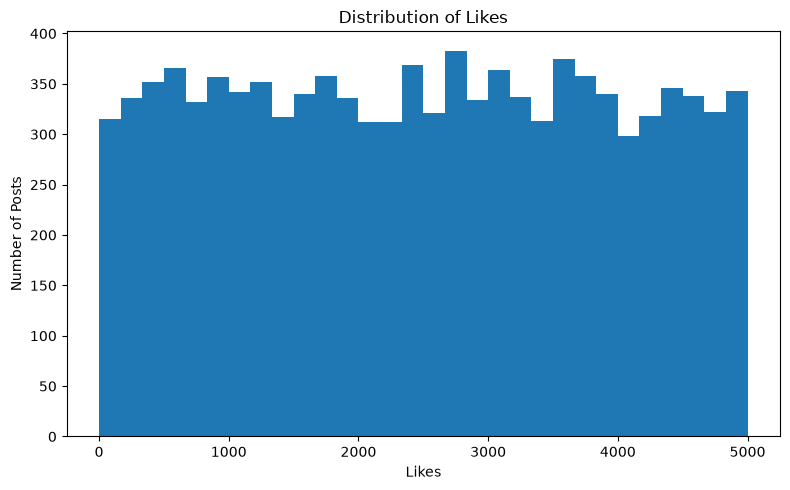

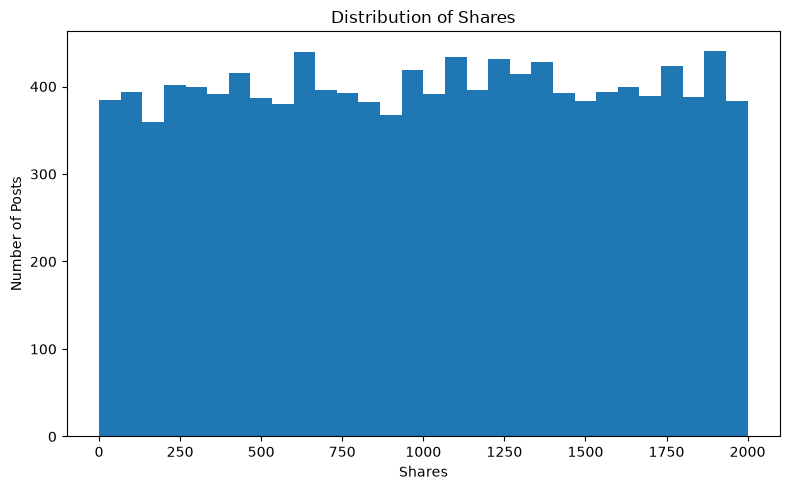

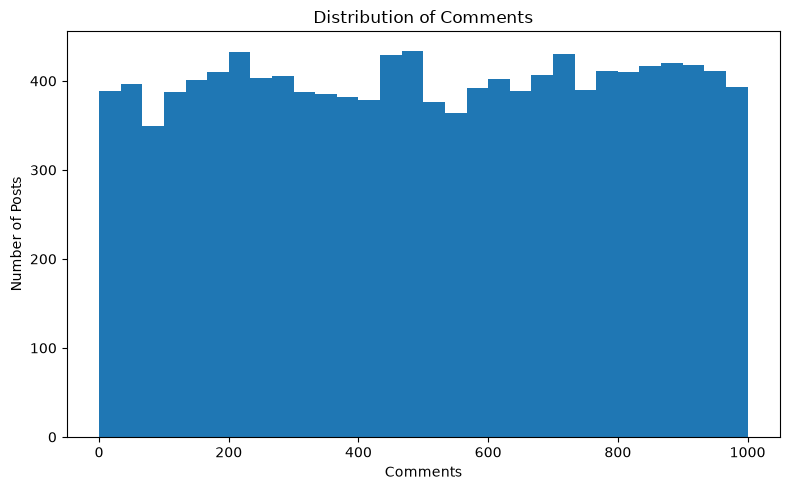

In [21]:
# Creating separate histograms for each engagement metric
# This makes it easier to understand the distribution of each value

for column in ["likes", "shares", "comments"]:

    plt.figure(figsize=(8, 5))

    # Removing missing values before creating the histogram
    values = df[column].dropna()

    # Creating the histogram
    plt.hist(values, bins=30)

    # Adding labels and title
    plt.title(f"Distribution of {column.title()}")
    plt.xlabel(column.title())
    plt.ylabel("Number of Posts")

    plt.tight_layout()

    # Saving each graph separately
    plt.savefig(f"03_{column}_distribution.png", dpi=300)

    plt.show()

Number of posts by month:


timestamp
2024-05    1038
2024-06     979
2024-07     996
2024-08    1015
2024-09     974
2024-10    1029
2024-11    1025
2024-12    1035
2025-01    1007
2025-02     914
2025-03    1013
2025-04     975
Freq: M, dtype: int64

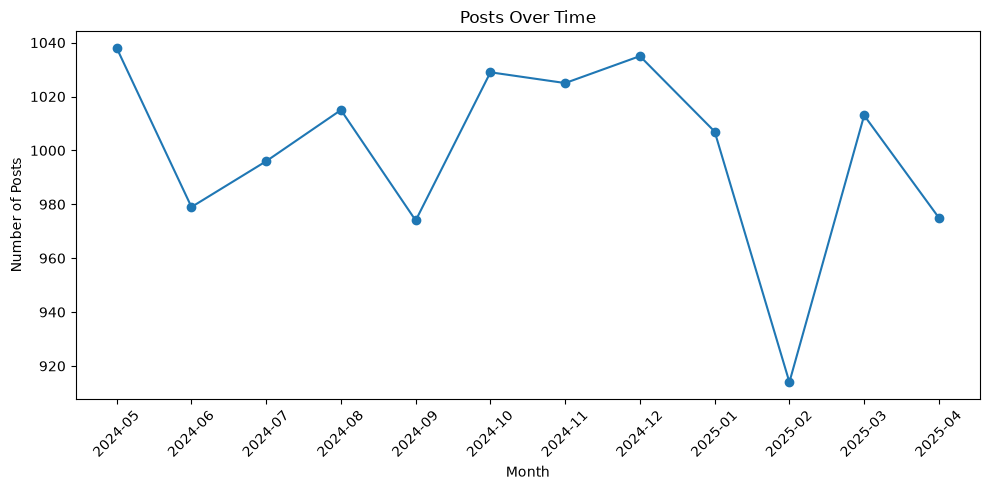

In [22]:
# Grouping the posts by month
# The timestamp was converted to datetime earlier,
# so we can use it to study posting activity over time

posts_over_time = df.groupby(
    df["timestamp"].dt.to_period("M")
).size()

print("Number of posts by month:")
display(posts_over_time)

# Creating a line chart to show posting activity over time
plt.figure(figsize=(10, 5))

plt.plot(
    posts_over_time.index.astype(str),
    posts_over_time.values,
    marker="o"
)

plt.title("Posts Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.tight_layout()

# Saving the chart for the EDA report
plt.savefig("04_posts_over_time.png", dpi=300)

plt.show()

Engagement correlation:


,likes,shares,comments
likes,1.00,-0.00,0.01
shares,-0.00,1.00,0.02
comments,0.01,0.02,1.00


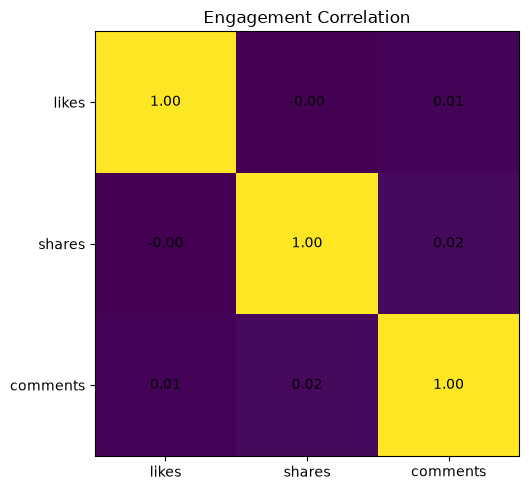

In [23]:
# Calculating the correlation between likes, shares and comments
# Correlation helps us understand whether two engagement measures
# tend to increase or decrease together

engagement_correlation = df[
    ["likes", "shares", "comments"]
].corr()

print("Engagement correlation:")
display(engagement_correlation.round(2))

# Creating a heatmap to make the correlations easier to compare
plt.figure(figsize=(7, 5))

plt.imshow(engagement_correlation, interpolation="nearest")

plt.xticks(
    range(len(engagement_correlation.columns)),
    engagement_correlation.columns
)

plt.yticks(
    range(len(engagement_correlation.columns)),
    engagement_correlation.columns
)

plt.title("Engagement Correlation")

# Displaying the correlation values inside the chart
for i in range(len(engagement_correlation.columns)):
    for j in range(len(engagement_correlation.columns)):
        plt.text(
            j,
            i,
            f"{engagement_correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

# Saving the correlation chart
plt.savefig("05_engagement_correlation.png", dpi=300)

plt.show()

In [24]:
# Counting how many posts were created by each user
# This helps us identify the most active users in the dataset

user_post_counts = df["user_id"].value_counts().head(10)

print("Top 10 users by number of posts:")
display(user_post_counts)

Top 10 users by number of posts:


user_id
user_zqv2vrf5    22
user_nfo3ih5u    19
user_n0ok02rt    18
user_8wk0j5ae    18
user_q3vs0uj7    18
user_0irp4abu    17
user_8w06w1qu    16
user_wyeb78qv    16
user_uerv85na    16
user_ujllj1n7    16
Name: count, dtype: int64

In [25]:
# Checking for unusually high engagement values
# We use the IQR method to identify possible outliers

for column in ["likes", "shares", "comments"]:

    # Calculating the first and third quartiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # Calculating the interquartile range
    IQR = Q3 - Q1

    # Calculating the upper limit for possible outliers
    upper_limit = Q3 + (1.5 * IQR)

    # Counting values above the upper limit
    outlier_count = (df[column] > upper_limit).sum()

    print(f"\n{column.title()}")
    print("Q1:", round(Q1, 2))
    print("Q3:", round(Q3, 2))
    print("Upper outlier limit:", round(upper_limit, 2))
    print("Number of possible outliers:", outlier_count)


Likes
Q1: 1236.0
Q3: 3722.75
Upper outlier limit: 7452.88
Number of possible outliers: 0

Shares
Q1: 510.0
Q3: 1501.0
Upper outlier limit: 2987.5
Number of possible outliers: 0

Comments
Q1: 253.0
Q3: 755.0
Upper outlier limit: 1508.0
Number of possible outliers: 0


In [26]:
# Performing one final check to make sure the cleaned dataset is ready

print("Final Validation")

print("Rows:", len(df))
print("Columns:", len(df.columns))

# Checking that exact duplicates have been removed
print("Duplicate rows:", df.duplicated().sum())

# Checking that negative likes have been corrected
print("Negative likes:", (df["likes"] < 0).sum())

# Checking that all timestamps were successfully converted
print("Invalid timestamps:", df["timestamp"].isna().sum())

# Checking the platform categories
print("\nPlatform categories:")
print(df["platform"].value_counts())

print("\nCleaning and EDA workflow completed successfully.")

Final Validation
Rows: 12000
Columns: 8
Duplicate rows: 0
Negative likes: 0
Invalid timestamps: 0

Platform categories:
platform
Facebook     2074
YouTube      2073
Twitter      2049
Reddit       2031
Instagram    1989
Unknown      1784
Name: count, dtype: int64

Cleaning and EDA workflow completed successfully.


## Key Findings and Conclusion

### Data Cleaning Findings

- The original dataset contained 12,360 rows.
- We removed 360 exact duplicate rows, leaving 12,000 unique records.
- Missing platform values were assigned to `Unknown` because there was not enough reliable evidence to determine the original platform.
- Missing text values were preserved because we did not have enough information to reconstruct the original content.
- Negative likes were treated as possible sign-flip corruption and converted to absolute values. This was a documented preprocessing assumption.
- Different timestamp formats were successfully converted into a standard datetime format with no conversion failures.
- HTML entities and unnecessary whitespace in the text content were cleaned without changing the actual meaning of the posts.

### EDA Findings

- We compared the number of posts across different platforms.
- We compared average likes, shares, and comments across platforms.
- We examined the distribution of the engagement metrics.
- We analyzed posting activity over time.
- We calculated correlations between likes, shares, and comments.
- We identified the most-liked posts and the most active users.
- We used the IQR method to identify possible engagement outliers. These values were retained because unusually high engagement can represent genuine activity.

### Final Result

The cleaned dataset contains 12,000 rows and 8 columns. There are no exact duplicate rows, no negative likes, and no invalid timestamps remaining.

We kept the original corrupted dataset unchanged so that the cleaning process remains transparent and reproducible.